### Advance Model Training 
we use Transfer Learning. We will take a massive, cutting-edge mathematical model that Google or researchers have already trained on millions of images, and we will "fine-tune" it to look specifically for brain tumors.

For medical imaging, DenseNet121 is an industry favorite (it's the architecture behind Stanford's famous CheXNet). It connects every layer to every other layer, which prevents the model from "forgetting" subtle tumor features as the data passes through the network.

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import DenseNet121
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Check GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"GPU ready: {physical_devices[0]}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("Using CPU. Training will take longer.")

Using CPU. Training will take longer.


### Data Loading

In [7]:
TRAIN_DIR = r'E:\fourth_sem\brain_tumor_detection\datasets\03_processed\Training'
TEST_DIR = r'E:\fourth_sem\brain_tumor_detection\datasets\03_processed\Testing'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading Datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Successfully loaded {NUM_CLASSES} classes: {class_names}")

# Optimize pipelines
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Loading Datasets...
Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Successfully loaded 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


### Calculate Class Weight

In [8]:
print("\nCalculating Class Weights to handle dataset imbalance...")

train_labels = []
# Process by batch rather than unbatching (much faster and saves RAM)
for images, labels in train_dataset:
    train_labels.extend(np.argmax(labels.numpy(), axis=1))

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Keras requires a dictionary format: {0: weight, 1: weight, etc.}
class_weights = dict(enumerate(class_weights_array))

print("Class Weights applied:")
for idx, weight in class_weights.items():
    print(f" - {class_names[idx]}: {weight:.4f}")


Calculating Class Weights to handle dataset imbalance...
Class Weights applied:
 - glioma: 0.9731
 - meningioma: 1.0182
 - notumor: 1.0117
 - pituitary: 0.9982


### Build the Transfer Learning Model

In [9]:
def build_advanced_model(num_classes):
    # 1. Load the pre-trained DenseNet121 model (excluding its original classification head)
    base_model = DenseNet121(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    
    # Freeze the base model so we don't destroy the pre-trained weights during initial training
    base_model.trainable = False 
    
    # 2. Build the complete model
    inputs = tf.keras.Input(shape=(224, 224, 3))
    
    # Data Augmentation (crucial for preventing overfitting in medical data)
    x = layers.RandomFlip("horizontal")(inputs)
    #x = layers.RandomRotation(0.1)(x)
    #x = layers.RandomZoom(0.1)(x)
    
    # DenseNet expects inputs scaled differently than our baseline, we use its built-in preprocess function
    x = tf.keras.applications.densenet.preprocess_input(x)
    
    # Pass through DenseNet
    x = base_model(x, training=False)
    
    # 3. Add our custom classification head
    x = layers.GlobalAveragePooling2D()(x) # Shrinks the output map into a 1D vector
    x = layers.BatchNormalization()(x)     # Stabilizes training
    x = layers.Dropout(0.5)(x)             # Heavy dropout to prevent memorizing the data
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model, base_model

advanced_model, base_model = build_advanced_model(NUM_CLASSES)
advanced_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,045,700 (26.88 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

### Advance Callbacks and Inintial Training
For an advanced model, EarlyStopping isn't enough. We add ReduceLROnPlateau. If the model gets "stuck" and stops improving, this callback automatically shrinks the learning rate, allowing the model to make finer, microscopic adjustments to find a better solution.

In [10]:
os.makedirs('../saved_models', exist_ok=True)
checkpoint_path = '../saved_models/advanced_densenet.keras'

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("\n--- Phase 1: Training custom classification head ---")
history_phase1 = advanced_model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=15, 
    callbacks=callbacks_list,
    class_weight=class_weights # <--- Weights Applied Here
)


--- Phase 1: Training custom classification head ---
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.7045 - loss: 0.7586 - val_accuracy: 0.8545 - val_loss: 0.4415 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.8362 - loss: 0.4413 - val_accuracy: 0.8848 - val_loss: 0.3255 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8562 - loss: 0.3856 - val_accuracy: 0.9045 - val_loss: 0.2801 - learning_rate: 0.0010
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.8692 - loss: 0.3458 - val_accuracy: 0.9107 - val_loss: 0.2516 - learning_rate: 0.0010
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.8779 - loss: 0.3238 - val_accuracy: 0.9241 - val_loss: 0.2287 - learning_rate: 0.0010
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.8770 - loss: 0.3250 - val_accuracy: 0.9241 - val_loss: 0.2208 - learning_rate: 0.0010
Epoch 7/15
140/140 ━━━━━━━━━

### Fine Tuning
Once the new top layers are trained, we "unfreeze" the very last blocks of the DenseNet model. We then train the whole thing together at an incredibly tiny learning rate. This adapts the actual DenseNet feature detectors specifically to brain tumors.

In [14]:
"""print("\n--- Phase 2: Fine-tuning top layers of the base model ---")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate
advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

history_phase2 = advanced_model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=10, 
    callbacks=callbacks_list,
    class_weight=class_weights # <--- Weights Applied Here Too!
)"""
print("\n--- Phase 2: Deep Fine-tuning with Focal Loss ---")

# 1. Unfreeze MORE layers (from 30 to 75) so it can learn subtle textures
base_model.trainable = True
for layer in base_model.layers[:-75]: 
    layer.trainable = False

# 2. Implement Focal Loss (Focuses heavily on the hard-to-classify Glioma/Meningioma images)
# Alpha helps with class imbalance, Gamma forces focus on hard examples (default is usually 2.0)
focal_loss = tf.keras.losses.CategoricalFocalCrossentropy(
    alpha=0.25, 
    gamma=2.0
)

# 3. Recompile with an even smaller learning rate to prevent destroying pre-trained weights
advanced_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss, # <--- FOCAL LOSS APPLIED HERE
    metrics=['accuracy']
)

# 4. Train Phase 2
history_phase2 = advanced_model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=12, # Slightly more epochs for the deeper tuning
    callbacks=callbacks_list,
    class_weight=class_weights 
)


--- Phase 2: Deep Fine-tuning with Focal Loss ---
Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.9230 - loss: 0.0265 - val_accuracy: 0.9339 - val_loss: 0.0215 - learning_rate: 1.0000e-05
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.9194 - loss: 0.0260 - val_accuracy: 0.9375 - val_loss: 0.0209 - learning_rate: 1.0000e-05
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.9179 - loss: 0.0267 - val_accuracy: 0.9384 - val_loss: 0.0204 - learning_rate: 1.0000e-05
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.9230 - loss: 0.0251 - val_accuracy: 0.9411 - val_loss: 0.0201 - learning_rate: 1.0000e-05
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.9212 - loss: 0.0247 - val_accuracy: 0.9402 - val_loss: 0.0198 - learning_rate: 1.0000e-05
Epoch 6/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9174 - loss: 0.0266 - val_accuracy: 0.9420 - val_loss: 0.0191 - learning_rate: 1.0000e-05
Epoch 7

### Final Evaluation


Evaluating the Advanced Model on the unseen Testing dataset...
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9038 - loss: 0.0654

--- Advanced Model Classification Report ---
              precision    recall  f1-score   support

      glioma       0.94      0.75      0.83       400
  meningioma       0.82      0.90      0.86       400
     notumor       0.92      0.99      0.96       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



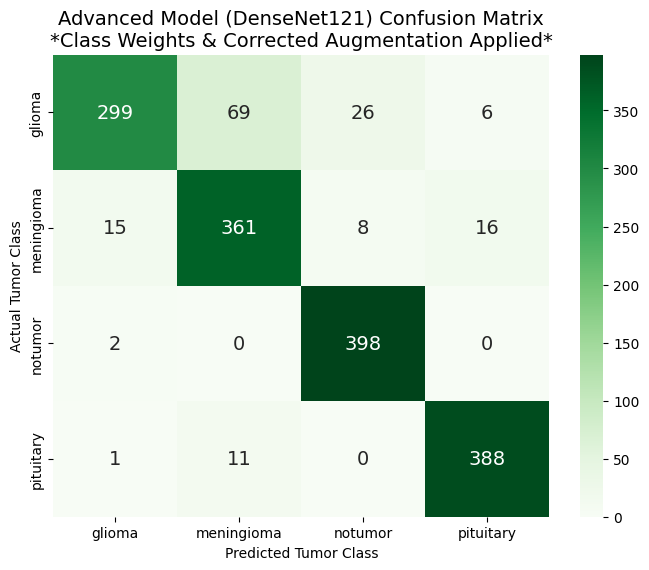

In [15]:
print("\nEvaluating the Advanced Model on the unseen Testing dataset...")
test_loss, test_accuracy = advanced_model.evaluate(test_dataset, verbose=1)

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred_probs.extend(advanced_model.predict(images, verbose=0))

y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Advanced Model Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.title('Advanced Model (DenseNet121) Confusion Matrix\n*Class Weights & Corrected Augmentation Applied*', fontsize=14)
plt.ylabel('Actual Tumor Class')
plt.xlabel('Predicted Tumor Class')
plt.show()